# Financial News EDA - FNSPID Dataset (raw_analyst_ratings.csv)

**Objective**: Perform comprehensive Exploratory Data Analysis as required for Task 1

**Dataset**: ~1.4M financial news headlines from Benzinga (2011–2020)

---

## 1. Setup & Data Loading

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
sns.set_style("whitegrid")

%matplotlib inline

In [3]:
import sys
import os

# Add project root (one directory above "notebooks")
sys.path.append(os.path.abspath(".."))


In [4]:
# Import your modular functions
from scripts.load_data import load_data,preprocess_data
from scripts.publisher_analysis import publisher_analysis
from scripts.text_analysis import run_topic_modeling, extract_keywords

In [ ]:
# 1. Load data
df = load_data("../data/raw_analyst_ratings.csv")

# 2. Correctly call the preprocess_data function
# Original: df=df.prerocess_data()
df = preprocess_data(df)

print(df.shape)
df.head() 

(1407328, 11)


,headline,url,publisher,date,stock,headline_length,year,month,weekday,hour,date_only
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54,A,39,2020,6,Friday,14,2020-06-05
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20,A,42,2020,6,Wednesday,14,2020-06-03
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07,A,29,2020,5,Tuesday,8,2020-05-26
3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06,A,44,2020,5,Friday,16,2020-05-22
4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59,A,87,2020,5,Friday,15,2020-05-22


## 2. Descriptive Statistics

In [5]:
"""headline length"""
pd.set_option('display.float_format', '{:.2f}'.format)
df['headline_length'].describe()

count   1407328.00
mean         73.12
std          40.74
min           3.00
25%          47.00
50%          64.00
75%          87.00
max         512.00
Name: headline_length, dtype: float64

<Axes: xlabel='publisher'>

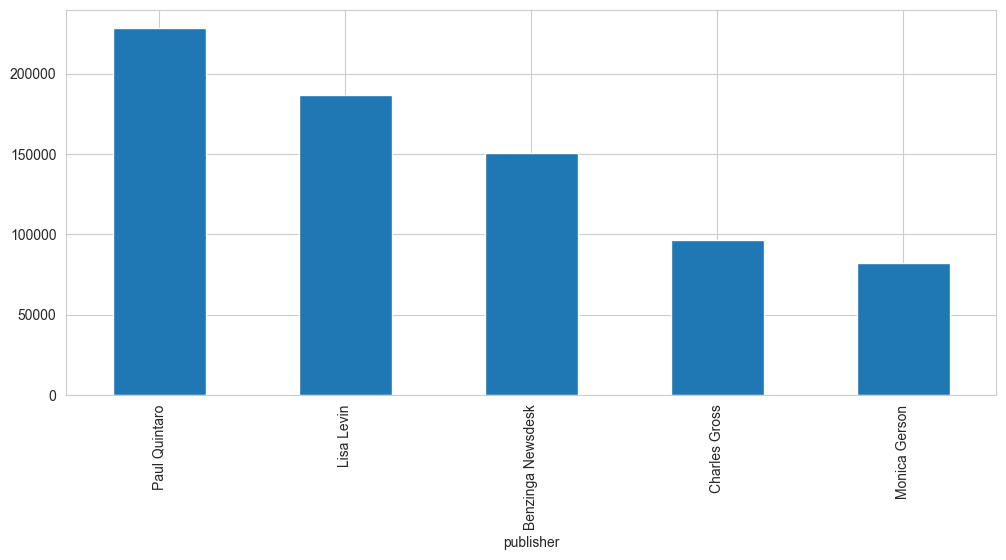

In [6]:
""" Most active publishers more on the coming sub-sections"""
df['publisher'].value_counts().head(5).plot(kind='bar', figsize=(12,5))

<Axes: xlabel='date'>

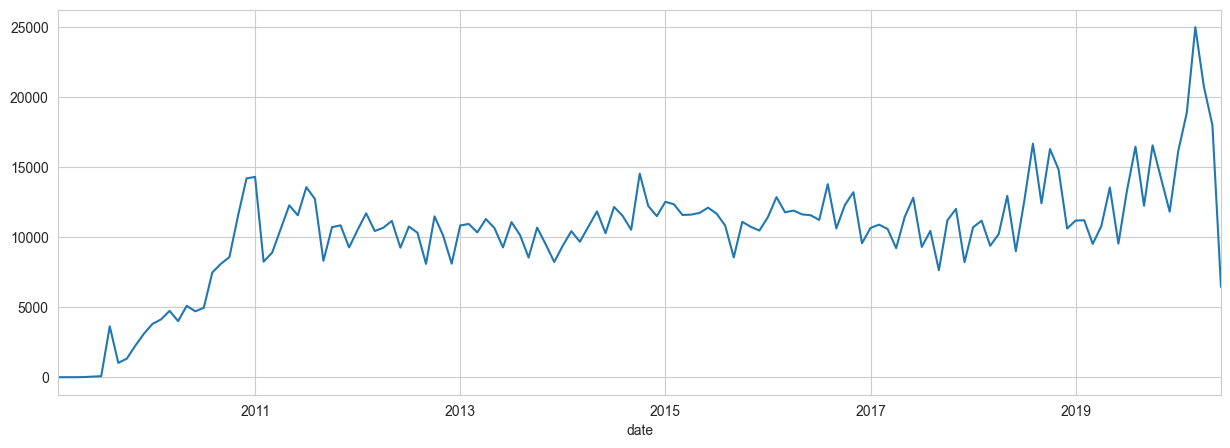

In [11]:
"""Analyze the publication dates more on future section on Time Series Analysis"""
df.set_index('date').resample('ME').size().plot(figsize=(15,5))

<Axes: title={'center': 'Articles per period'}, xlabel='month/year'>

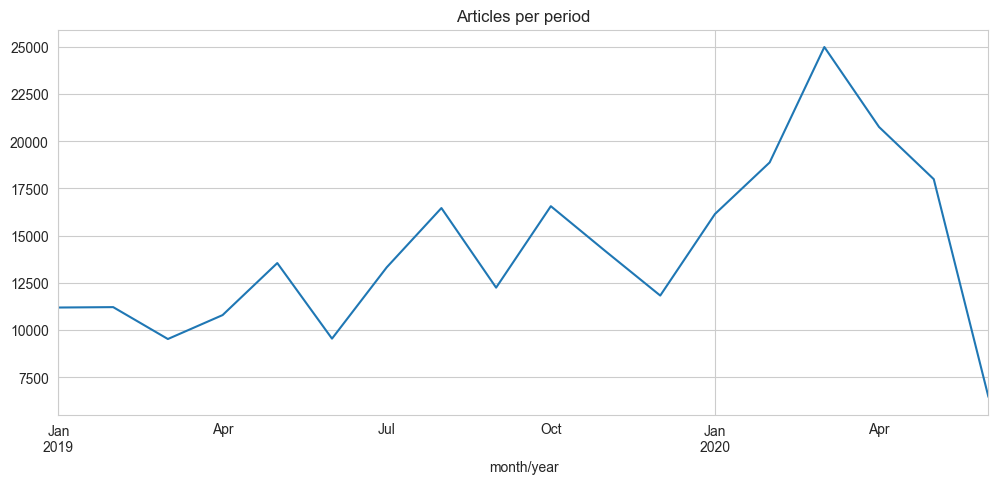

In [12]:
"""looked deeper into 2019 and 2020 because there was an interesting rise then decline between these years noticed the dataset is upto 6th month of 2020"""
filtered_years=df[df['date'].dt.year.isin([2020,2019])].copy()
filtered_years['month/year'] = filtered_years['date'].dt.to_period('M')
articles_per_month_filtered = filtered_years.groupby('month/year').size()
articles_per_month_filtered.plot(kind='line', figsize=(12,5), title="Articles per period")


Noticed that high numbers of published financial news articles were within February–May 2020, during the peak of the COVID-19 pandemic market crash.

This period had:

- The fastest stock market crash in history

- The largest daily drops in the S&P 500 since 1987

- Massive volatility, circuit breakers, global lockdown announcements


## 3. Text Analysis(Topic Modeling)

In [7]:
# Extract keywords using TF-IDF version (down-weights very common but boring words across documents)
keywords = extract_keywords(df, top_n=30)
display(keywords)

,tfidf_sum
stock,21314.54
benzinga,15468.62
market,12732.50
vs,12558.28
est,11447.44
earn,11143.65
report,11062.53
downgrad,10516.89
upgrad,10355.96
ep,10203.89


In [8]:
run_topic_modeling(df, n_topics=20)

Topic 0: hit 52week high | 52week high | high | hit 52week | hit | stock hit 52week | stock hit | 52week | stock | 52week high friday | high friday | 52week high thursday | high thursday | high tuesday | 52week high tuesday
Topic 1: top upgrad | benzinga top upgrad | upgrad | benzinga top | benzinga | top | upgrad downgrad | top upgrad downgrad | downgrad | 2019 | 2017 | 2018 | upgrad downgrad januari | downgrad januari | 2020
Topic 2: stock move | move | session | premarket session | stock | premarket | move tuesday | stock move tuesday | tuesday | move friday | stock move friday | move monday | stock move monday | friday | monday
Topic 3: biggest mover | mover | mover yesterday | biggest mover yesterday | biggest | yesterday | biggest mover friday | mover friday | friday | 50 biggest | 50 biggest mover | 60 biggest mover | 60 biggest | 60 | 55 biggest
Topic 4: vs | est | ep | report | sale | revenu | est revenu | vs est | q4 | q1 | q2 | q3 | see | adj | estim
Topic 5: new 52week | se

## 4. Time Series Analysis

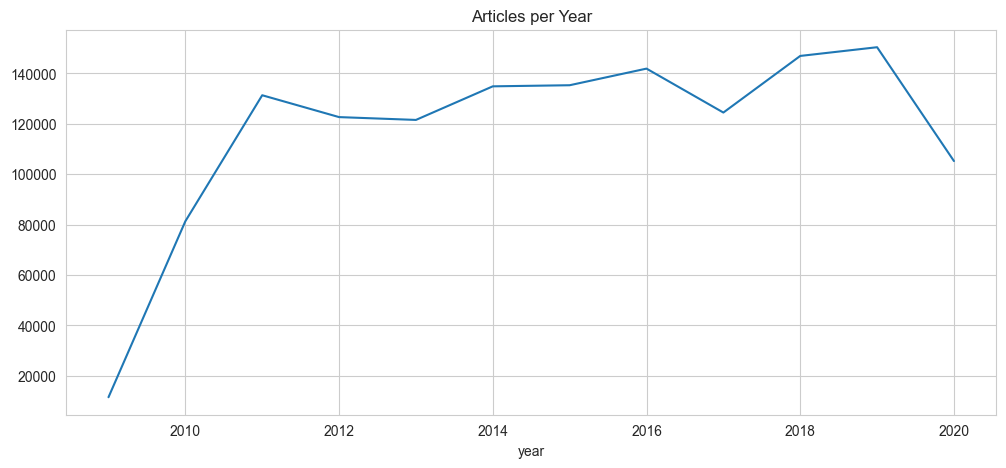

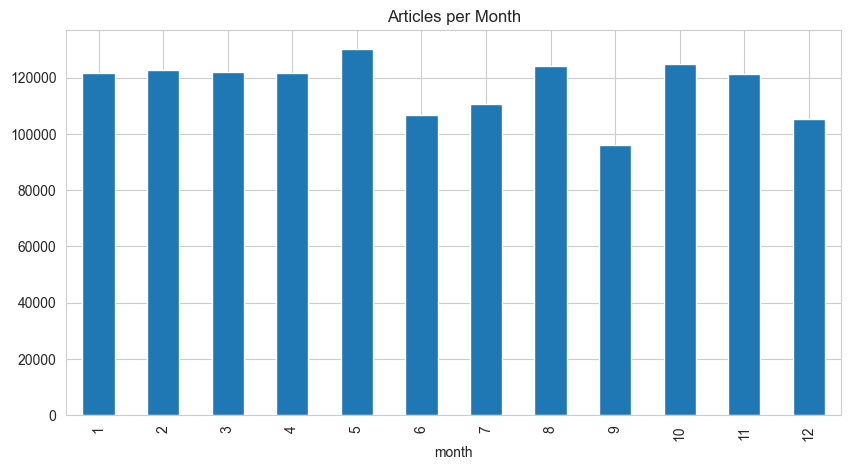

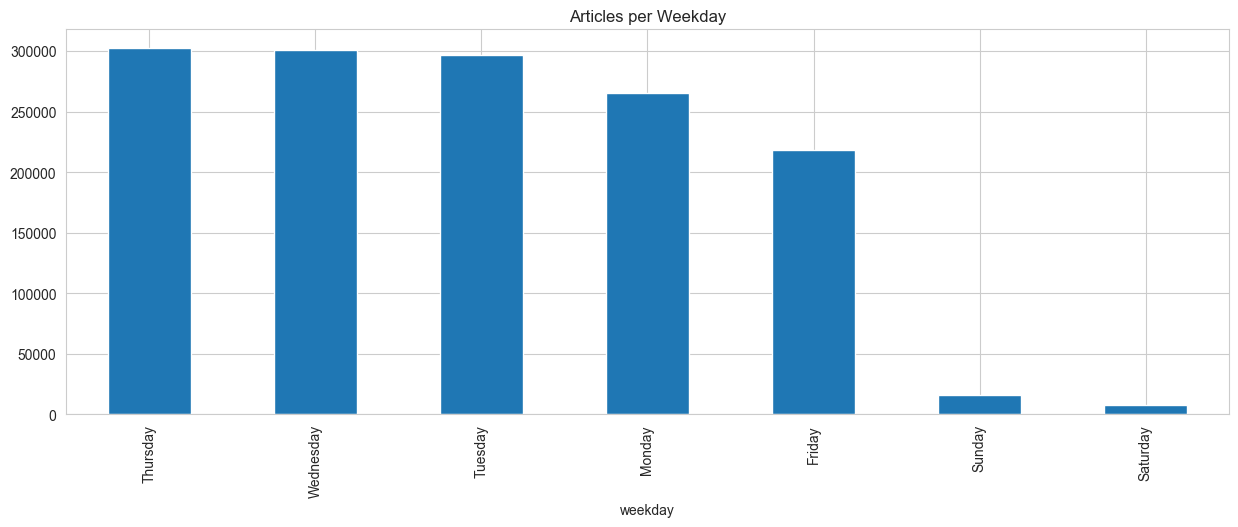

In [14]:
# articles per year
df.groupby('year').size().plot(kind='line', title="Articles per Year", figsize=(12,5))
plt.show()

# articles per month
df.groupby('month').size().plot(kind='bar', figsize=(10,5), title="Articles per Month")
plt.show()

#articles per weekday
df['weekday'].value_counts().plot(kind='bar',title="Articles per Weekday", figsize=(15,5))
plt.show()

In [ ]:
# spikes in article publications
spike_dates=df['date_only'].value_counts().head(20)
spike_dates

date_only
2020-03-12    2739
2020-02-28    1620
2020-03-19    1595
2020-02-27    1567
2020-03-06    1428
2020-05-07    1398
2020-03-23    1391
2020-04-29    1389
2020-03-11    1384
2020-04-30    1327
2019-08-01    1270
2020-04-15    1253
2018-10-30    1228
2020-01-22    1198
2020-03-16    1181
2019-08-07    1180
2018-08-02    1175
2020-05-06    1175
2020-01-21    1171
2020-03-09    1170
Name: count, dtype: int64


further explanation on spike dates:

| Date        | News Count | Key Event / Reason for High News Volume |
|-------------|------------|------------------------------------------|
| 2020-02-27  | 1567       | Stock Market Decline: Dow Jones dropped over 1,100 points, signaling major economic crisis fears. |
| 2020-02-28  | 1620       | Global Spread: Stock markets saw massive losses; major case increases in the US, UK, and South Korea. |
| 2020-03-06  | 1428       | 100K Cases: Global COVID-19 cases surpassed 100,000; major response efforts began (e.g., Italy school closures). |
| 2020-03-11  | 1384       | Pandemic Declared: WHO officially declared COVID-19 a global pandemic; US announced Europe travel ban. |
| 2020-03-12  | 2739       | COVID-19 Panic Peak: "Black Thursday" stock market crash, Tom Hanks tested positive, major sports/Broadway shut down. |
| 2020-03-19  | 1595       | Lockdowns Begin: First widespread “stay-at-home” or shelter-in-place orders in US cities/states. |
| 2020-03-23  | 1391       | Economic Action: More strict lockdowns enacted; US Congress finalized the massive CARES Act stimulus package. |
| 2020-04-29  | 1389       | Reopening Debates: Focus on state-by-state plans to reopen the economy and the peak of case numbers in many regions. |
| 2020-04-30  | 1327       | Reopening Debates: Continued coverage on reopening plans and peak case numbers. |
| 2020-05-07  | 1398       | Reopening & Data: Focus on phased lifting of lockdowns and devastating unemployment/economic reports. |


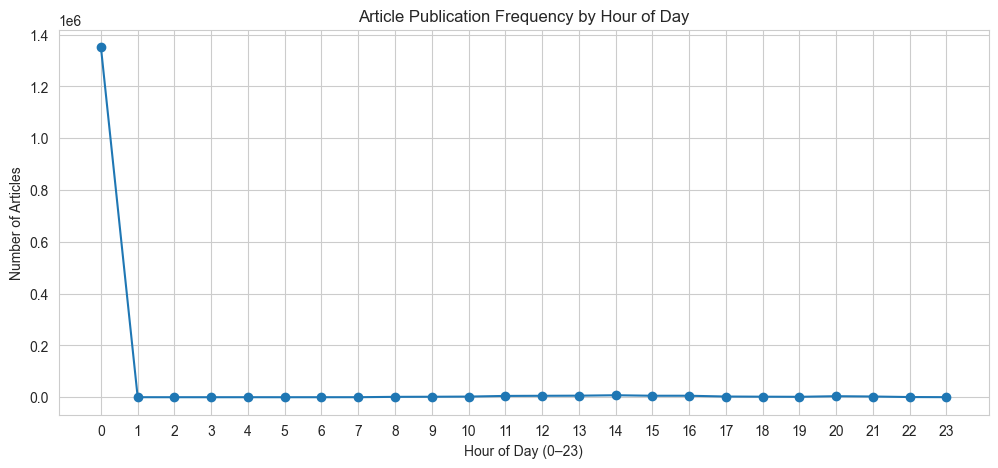

In [15]:
hour_counts=df['hour'].value_counts().sort_index()

plt.figure(figsize=(12,5))
plt.plot(hour_counts.index, hour_counts.values, marker='o')

plt.title("Article Publication Frequency by Hour of Day")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Number of Articles")
plt.xticks(range(0,24))   # show all hour ticks
plt.grid(True)

plt.show()

- Notice that most news is released at 00:00

## 4. Publisher Analysis

Top 15 Publishers:
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Name: count, dtype: int64


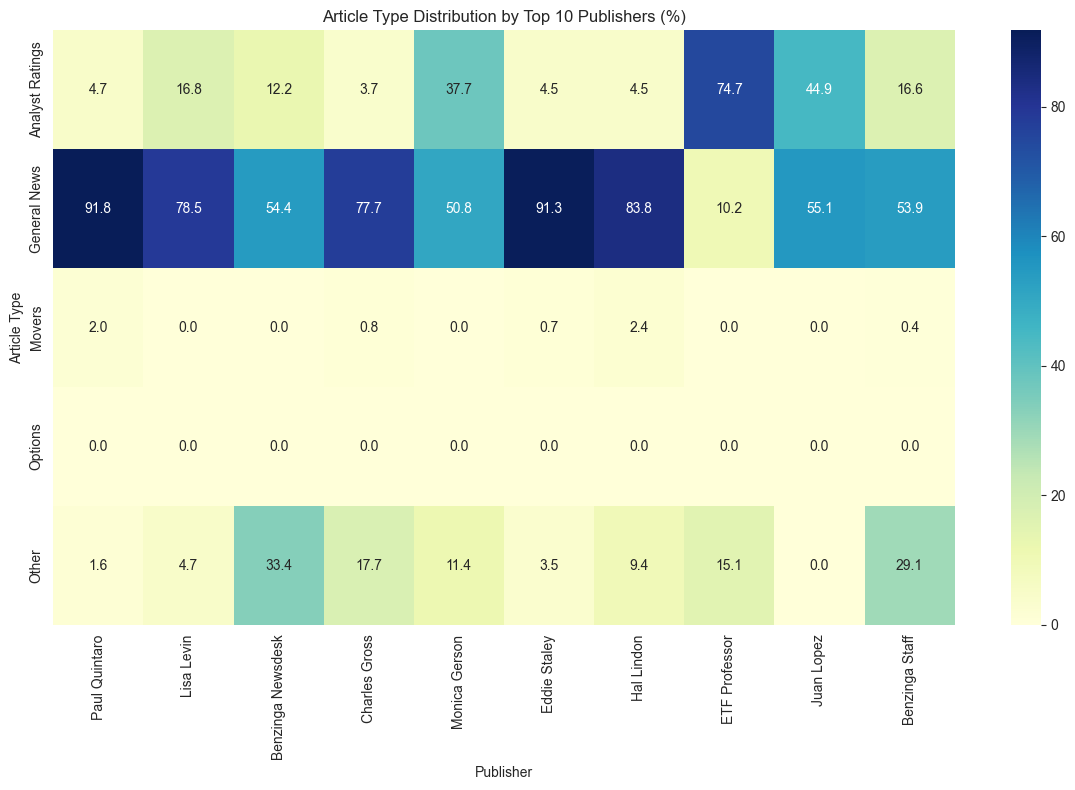

In [16]:
publisher_analysis(df)

In [13]:
# Save cleaned data
df_clean = df.drop(["year", 'month', "weekday", "hour", 'date_only'], axis=1)
df_clean.to_csv("../data/processed/raw_analyst_ratings_clean.csv")